### Cell 1 — Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# Feature Selection
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Class Imbalance
from imblearn.combine import SMOTETomek

# Settings
os.chdir('/Users/cirrus/Desktop/PMOS_PROJECT/notebook')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries imported successfully')

✅ All libraries imported successfully


### Cell 2 — Load Data from Block 1

In [3]:
df = pd.read_csv('../data/processed/pmos_eda_clean.csv')

print(f'✅ Data loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nTarget distribution:')
print(df['PCOS (Y/N)'].value_counts())

✅ Data loaded: 541 rows × 46 columns

Target distribution:
PCOS (Y/N)
0    364
1    177
Name: count, dtype: int64


### Cell 3 — Clean Column Names

In [4]:
# Strip all leading/trailing spaces from column names
df.columns = df.columns.str.strip()

print('✅ Column names cleaned')
print('\nAll columns after cleaning:')
for i, col in enumerate(df.columns, 1):
    print(f'{i:2d}. "{col}"')

✅ Column names cleaned

All columns after cleaning:
 1. "Sl. No"
 2. "Patient File No."
 3. "PCOS (Y/N)"
 4. "Age (yrs)"
 5. "Weight (Kg)"
 6. "Height(Cm)"
 7. "BMI"
 8. "Blood Group"
 9. "Pulse rate(bpm)"
10. "RR (breaths/min)"
11. "Hb(g/dl)"
12. "Cycle(R/I)"
13. "Cycle length(days)"
14. "Marraige Status (Yrs)"
15. "Pregnant(Y/N)"
16. "No. of aborptions"
17. "I   beta-HCG(mIU/mL)"
18. "II    beta-HCG(mIU/mL)"
19. "FSH(mIU/mL)"
20. "LH(mIU/mL)"
21. "FSH/LH"
22. "Hip(inch)"
23. "Waist(inch)"
24. "Waist:Hip Ratio"
25. "TSH (mIU/L)"
26. "AMH(ng/mL)"
27. "PRL(ng/mL)"
28. "Vit D3 (ng/mL)"
29. "PRG(ng/mL)"
30. "RBS(mg/dl)"
31. "Weight gain(Y/N)"
32. "hair growth(Y/N)"
33. "Skin darkening (Y/N)"
34. "Hair loss(Y/N)"
35. "Pimples(Y/N)"
36. "Fast food (Y/N)"
37. "Reg.Exercise(Y/N)"
38. "BP _Systolic (mmHg)"
39. "BP _Diastolic (mmHg)"
40. "Follicle No. (L)"
41. "Follicle No. (R)"
42. "Avg. F size (L) (mm)"
43. "Avg. F size (R) (mm)"
44. "Endometrium (mm)"
45. "Unnamed: 44"
46. "LH_FSH_Ratio"


### Cell 4 — Fix Dtype Issues

In [5]:
# Check object columns
object_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Object columns found: {object_cols}')

# Convert to numeric
for col in object_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    print(f'  ✅ {col} → converted to float | Missing created: {df[col].isnull().sum()}')

print(f'\nObject columns remaining: {df.select_dtypes(include="object").columns.tolist()}')

Object columns found: ['II    beta-HCG(mIU/mL)', 'Unnamed: 44']
  ✅ II    beta-HCG(mIU/mL) → converted to float | Missing created: 1
  ✅ Unnamed: 44 → converted to float | Missing created: 540

Object columns remaining: []


### Cell 5 — Impute Missing Values

In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print('=== MISSING VALUES BEFORE IMPUTATION ===')
print(missing)

for col in missing.index:
    if df[col].nunique() <= 2:
        fill_val = df[col].mode()[0]
        strategy = 'mode'
    else:
        fill_val = df[col].median()
        strategy = 'median'
    
    df[col] = df[col].fillna(fill_val)
    print(f'  ✅ {col} → imputed with {strategy} ({fill_val:.3f})')

print(f'\nTotal missing values remaining: {df.isnull().sum().sum()}')

=== MISSING VALUES BEFORE IMPUTATION ===
Marraige Status (Yrs)       1
II    beta-HCG(mIU/mL)      1
AMH(ng/mL)                  1
Fast food (Y/N)             1
Unnamed: 44               540
dtype: int64
  ✅ Marraige Status (Yrs) → imputed with median (7.000)
  ✅ II    beta-HCG(mIU/mL) → imputed with median (1.990)
  ✅ AMH(ng/mL) → imputed with median (3.700)
  ✅ Fast food (Y/N) → imputed with mode (1.000)
  ✅ Unnamed: 44 → imputed with mode (7.000)

Total missing values remaining: 0


### Cell 6 —  Drop Irrelevant Columns

In [8]:
cols_to_drop = [
    'Sl. No',
    'Patient File No.',
    'Unnamed: 44',
    'Blood Group',
    'Pregnant(Y/N)',
]

# Only drop columns that exist
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=cols_to_drop)

print(f'✅ Dropped {len(cols_to_drop)} columns')
print(f'   Dropped: {cols_to_drop}')
print(f'   Remaining shape: {df.shape}')

✅ Dropped 5 columns
   Dropped: ['Sl. No', 'Patient File No.', 'Unnamed: 44', 'Blood Group', 'Pregnant(Y/N)']
   Remaining shape: (541, 41)


### Cell 7 — Define Target and Features

In [9]:
target_col = 'PCOS (Y/N)'

X = df.drop(columns=[target_col])
y = df[target_col]

print(f'Features (X) : {X.shape}')
print(f'Target   (y) : {y.shape}')
print(f'\nFeature list:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2d}. {col}')

Features (X) : (541, 40)
Target   (y) : (541,)

Feature list:
   1. Age (yrs)
   2. Weight (Kg)
   3. Height(Cm)
   4. BMI
   5. Pulse rate(bpm)
   6. RR (breaths/min)
   7. Hb(g/dl)
   8. Cycle(R/I)
   9. Cycle length(days)
  10. Marraige Status (Yrs)
  11. No. of aborptions
  12. I   beta-HCG(mIU/mL)
  13. II    beta-HCG(mIU/mL)
  14. FSH(mIU/mL)
  15. LH(mIU/mL)
  16. FSH/LH
  17. Hip(inch)
  18. Waist(inch)
  19. Waist:Hip Ratio
  20. TSH (mIU/L)
  21. AMH(ng/mL)
  22. PRL(ng/mL)
  23. Vit D3 (ng/mL)
  24. PRG(ng/mL)
  25. RBS(mg/dl)
  26. Weight gain(Y/N)
  27. hair growth(Y/N)
  28. Skin darkening (Y/N)
  29. Hair loss(Y/N)
  30. Pimples(Y/N)
  31. Fast food (Y/N)
  32. Reg.Exercise(Y/N)
  33. BP _Systolic (mmHg)
  34. BP _Diastolic (mmHg)
  35. Follicle No. (L)
  36. Follicle No. (R)
  37. Avg. F size (L) (mm)
  38. Avg. F size (R) (mm)
  39. Endometrium (mm)
  40. LH_FSH_Ratio


### Cell 8 — Chi-Square Test

Binary columns for Chi-square: ['Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)']

=== CHI-SQUARE TEST RESULTS ===
             Feature  Chi2 Score  P-Value  Significant (p<0.05)
Skin darkening (Y/N)      84.871    0.000                  True
    hair growth(Y/N)      84.855    0.000                  True
    Weight gain(Y/N)      65.554    0.000                  True
     Fast food (Y/N)      37.077    0.000                  True
        Pimples(Y/N)      22.588    0.000                  True
      Hair loss(Y/N)       8.847    0.003                  True
   Reg.Exercise(Y/N)       1.737    0.187                 False


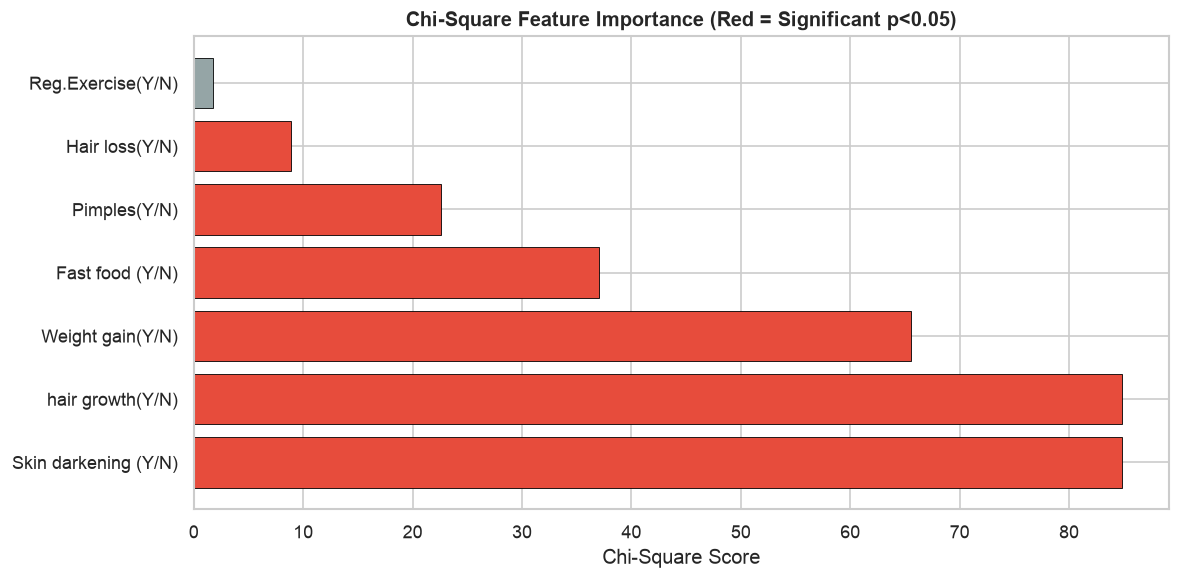

In [10]:
# Identify binary columns for chi-square
binary_cols = [
    col for col in X.columns
    if X[col].dropna().isin([0, 1]).all()
]

print(f'Binary columns for Chi-square: {binary_cols}')

# Run chi-square
X_binary = X[binary_cols].fillna(0)
chi2_scores, chi2_pvals = chi2(X_binary, y)

chi2_df = pd.DataFrame({
    'Feature'             : binary_cols,
    'Chi2 Score'          : chi2_scores,
    'P-Value'             : chi2_pvals,
    'Significant (p<0.05)': chi2_pvals < 0.05
}).sort_values('Chi2 Score', ascending=False)

print('\n=== CHI-SQUARE TEST RESULTS ===')
print(chi2_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in chi2_df['P-Value']]
plt.barh(chi2_df['Feature'], chi2_df['Chi2 Score'],
         color=colors, edgecolor='black', linewidth=0.5)
plt.xlabel('Chi-Square Score')
plt.title('Chi-Square Feature Importance (Red = Significant p<0.05)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/B2_01_chi2_scores.png', bbox_inches='tight')
plt.show()

### Cell 9 — ANOVA F-Test

Continuous columns for ANOVA: 31

=== ANOVA F-TEST RESULTS ===
               Feature  F-Score  P-Value  Significant (p<0.05)
      Follicle No. (R)  390.836    0.000                  True
      Follicle No. (L)  308.520    0.000                  True
            AMH(ng/mL)   40.427    0.000                  True
           Weight (Kg)   25.349    0.000                  True
                   BMI   22.350    0.000                  True
    Cycle length(days)   17.735    0.000                  True
             Age (yrs)   15.753    0.000                  True
           Waist(inch)   15.009    0.000                  True
             Hip(inch)   14.582    0.000                  True
  Avg. F size (L) (mm)    9.705    0.002                  True
 Marraige Status (Yrs)    6.978    0.008                  True
      Endometrium (mm)    6.201    0.013                  True
  Avg. F size (R) (mm)    5.193    0.023                  True
       Pulse rate(bpm)    4.583    0.033               

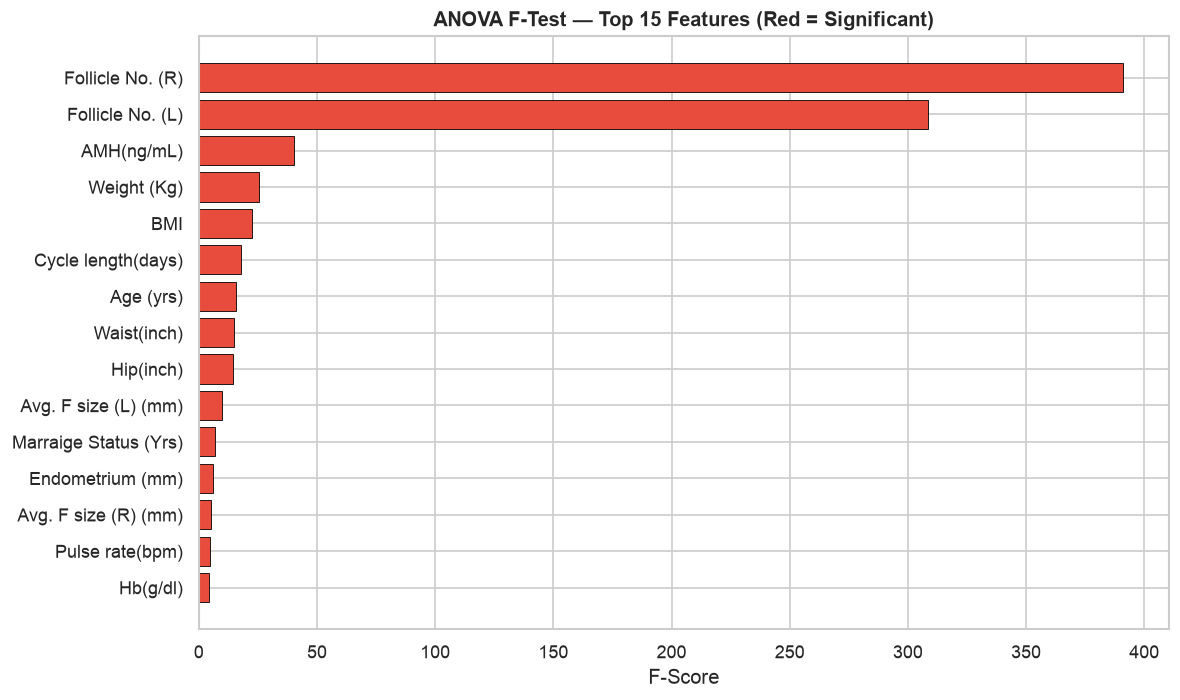

In [11]:
# Continuous columns only
continuous_cols = [
    col for col in X.columns
    if col not in binary_cols and X[col].nunique() > 5
]

print(f'Continuous columns for ANOVA: {len(continuous_cols)}')

X_continuous = X[continuous_cols].fillna(X[continuous_cols].median())
f_scores, f_pvals = f_classif(X_continuous, y)

anova_df = pd.DataFrame({
    'Feature'             : continuous_cols,
    'F-Score'             : f_scores,
    'P-Value'             : f_pvals,
    'Significant (p<0.05)': f_pvals < 0.05
}).sort_values('F-Score', ascending=False)

print('\n=== ANOVA F-TEST RESULTS ===')
print(anova_df.to_string(index=False))

# Plot top 15
top_anova = anova_df.head(15)
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if p < 0.05 else '#95a5a6' for p in top_anova['P-Value']]
plt.barh(top_anova['Feature'], top_anova['F-Score'],
         color=colors, edgecolor='black', linewidth=0.5)
plt.xlabel('F-Score')
plt.title('ANOVA F-Test — Top 15 Features (Red = Significant)',
          fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/plots/B2_02_anova_scores.png', bbox_inches='tight')
plt.show()

### Cell 10 — Mutual Information

=== MUTUAL INFORMATION SCORES ===
               Feature  MI Score
      Follicle No. (R)     0.267
      Follicle No. (L)     0.204
      hair growth(Y/N)     0.123
      Weight gain(Y/N)     0.098
    Cycle length(days)     0.098
            Cycle(R/I)     0.095
  Skin darkening (Y/N)     0.079
            AMH(ng/mL)     0.076
       Fast food (Y/N)     0.072
                FSH/LH     0.068
            PRL(ng/mL)     0.067
          LH_FSH_Ratio     0.065
           TSH (mIU/L)     0.036
            LH(mIU/mL)     0.033
             Hip(inch)     0.031
       Waist:Hip Ratio     0.029
  Avg. F size (L) (mm)     0.029
        Vit D3 (ng/mL)     0.028
           Weight (Kg)     0.026
           FSH(mIU/mL)     0.025
        Hair loss(Y/N)     0.021
          Pimples(Y/N)     0.020
      RR (breaths/min)     0.018
            PRG(ng/mL)     0.018
           Waist(inch)     0.018
       Pulse rate(bpm)     0.011
                   BMI     0.010
  I   beta-HCG(mIU/mL)     0.009
     No. 

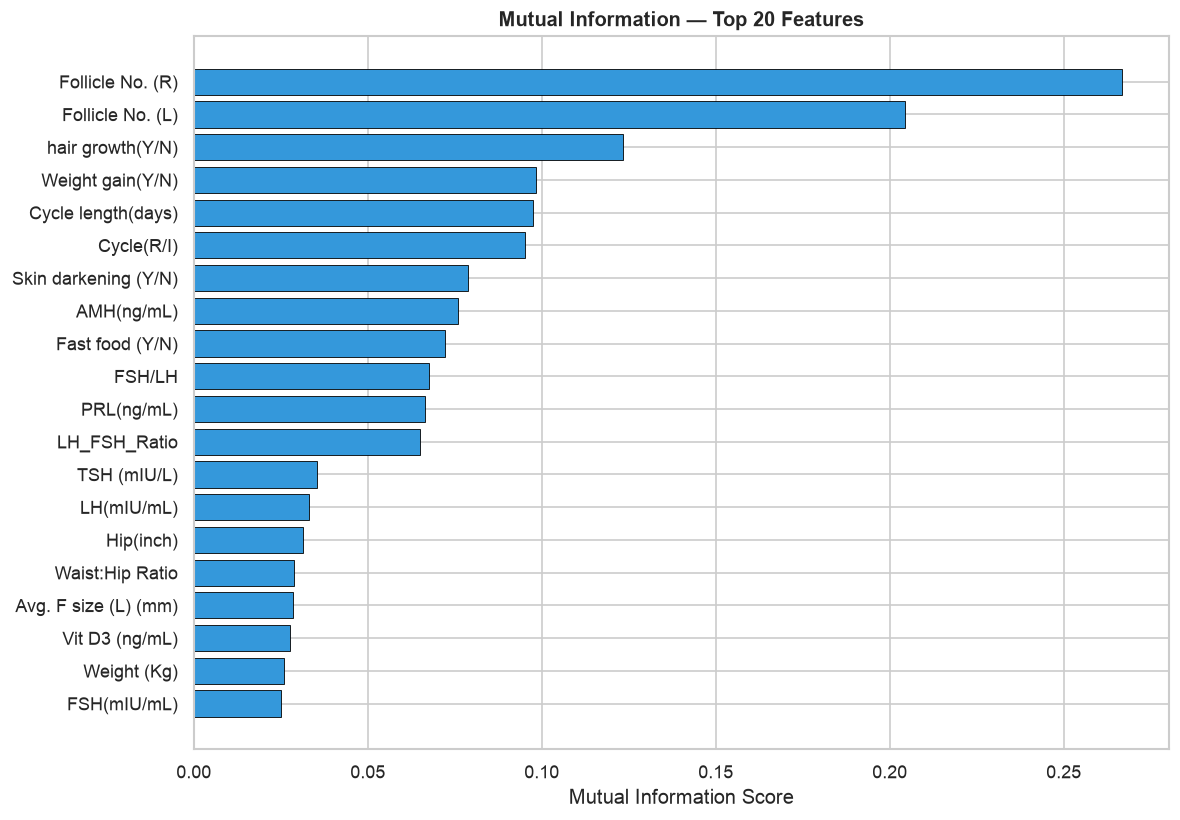

In [12]:
X_filled = X.fillna(X.median())

mi_scores = mutual_info_classif(X_filled, y, random_state=42)

mi_df = pd.DataFrame({
    'Feature' : X.columns,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=False)

print('=== MUTUAL INFORMATION SCORES ===')
print(mi_df.to_string(index=False))

# Plot top 20
top_mi = mi_df.head(20)
plt.figure(figsize=(10, 7))
plt.barh(top_mi['Feature'], top_mi['MI Score'],
         color='#3498db', edgecolor='black', linewidth=0.5)
plt.xlabel('Mutual Information Score')
plt.title('Mutual Information — Top 20 Features',
          fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/plots/B2_03_mutual_information.png', bbox_inches='tight')
plt.show()

### Cell 11 — Combined Feature Ranking

In [13]:
def normalise(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

# ANOVA on all features
X_filled = X.fillna(X.median())
f_all, _ = f_classif(X_filled, y)
anova_all = pd.Series(f_all, index=X.columns)

# MI already computed
mi_all = pd.Series(mi_scores, index=X.columns)

# Combined ranking
ranking_df = pd.DataFrame({
    'ANOVA (norm)': normalise(anova_all),
    'MI (norm)'   : normalise(mi_all),
})
ranking_df['Combined Score'] = ranking_df.mean(axis=1)
ranking_df = ranking_df.sort_values('Combined Score', ascending=False)

print('=== COMBINED FEATURE RANKING ===')
print(ranking_df.round(3).to_string())

# Features with combined score > 0.05
selected_features = ranking_df[ranking_df['Combined Score'] > 0.05].index.tolist()
print(f'\n✅ Features selected (score > 0.05): {len(selected_features)}')
print(selected_features)

=== COMBINED FEATURE RANKING ===
                        ANOVA (norm)  MI (norm)  Combined Score
Follicle No. (R)               1.000      1.000           1.000
Follicle No. (L)               0.789      0.766           0.777
hair growth(Y/N)               0.380      0.463           0.421
Weight gain(Y/N)               0.333      0.369           0.351
Skin darkening (Y/N)           0.403      0.295           0.349
Cycle(R/I)                     0.265      0.356           0.311
Fast food (Y/N)                0.227      0.270           0.249
Cycle length(days)             0.045      0.365           0.205
AMH(ng/mL)                     0.103      0.284           0.194
FSH/LH                         0.000      0.253           0.127
PRL(ng/mL)                     0.000      0.249           0.125
LH_FSH_Ratio                   0.006      0.243           0.125
Pimples(Y/N)                   0.123      0.076           0.099
Weight (Kg)                    0.065      0.097           0.081
Hip(inc

### Now Cell 12 — LASSO Feature Selection!

Best alpha: 0.0132

✅ LASSO selected 16 features:
Follicle No. (R)         0.166
hair growth(Y/N)         0.072
Skin darkening (Y/N)     0.065
Weight gain(Y/N)         0.062
Cycle(R/I)               0.056
Follicle No. (L)         0.046
Pimples(Y/N)             0.026
LH(mIU/mL)               0.023
Fast food (Y/N)          0.022
AMH(ng/mL)               0.018
Marraige Status (Yrs)   -0.013
I   beta-HCG(mIU/mL)    -0.008
Cycle length(days)      -0.007
Pulse rate(bpm)          0.006
PRG(ng/mL)              -0.004
Age (yrs)               -0.002

❌ LASSO dropped 24 features:
['Weight (Kg)', 'Height(Cm)', 'BMI', 'RR (breaths/min)', 'Hb(g/dl)', 'No. of aborptions', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'RBS(mg/dl)', 'Hair loss(Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)', 'LH_FSH_Ratio']


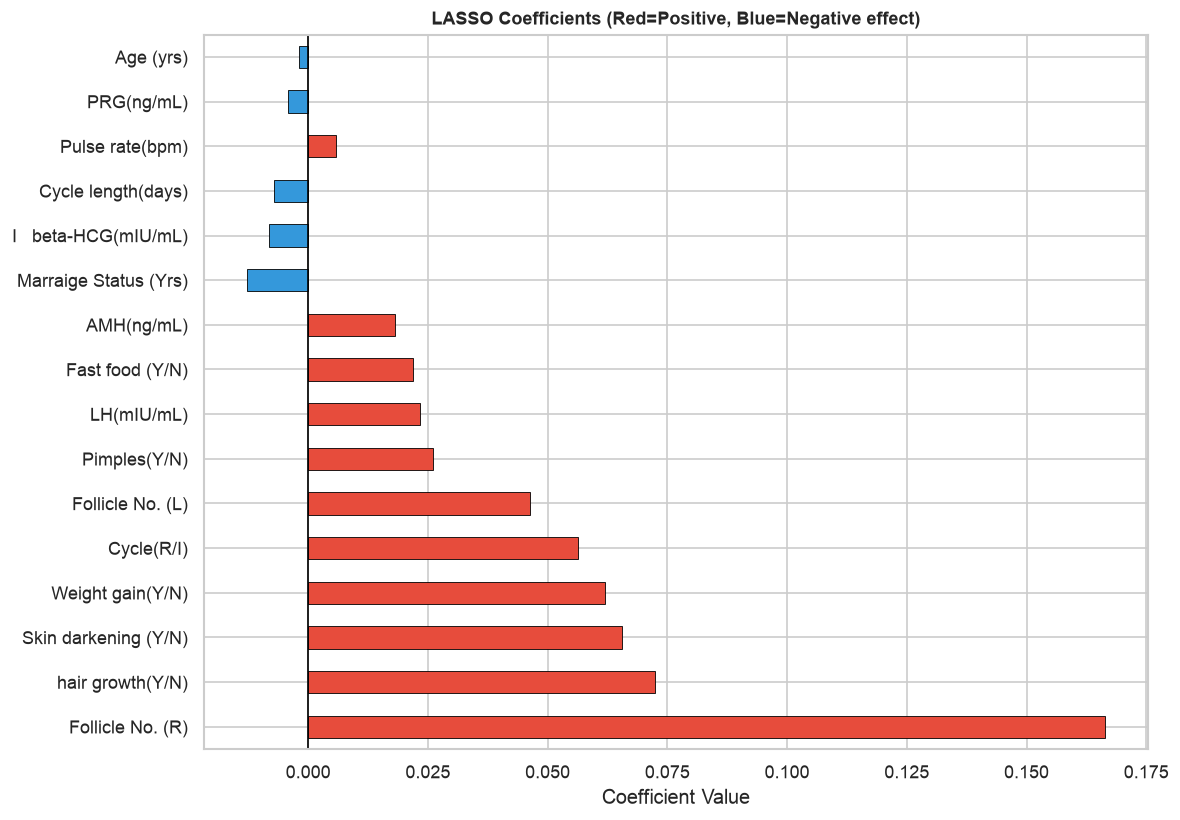

In [14]:
# Scale features — LASSO is scale sensitive
scaler_temp = StandardScaler()
X_filled = X.fillna(X.median())
X_scaled_temp = scaler_temp.fit_transform(X_filled)
X_scaled_df = pd.DataFrame(X_scaled_temp, columns=X.columns)

# LassoCV — finds best alpha via cross validation
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X_scaled_df, y)

print(f'Best alpha: {lasso.alpha_:.4f}')

# Features with non-zero coefficients
lasso_coef = pd.Series(lasso.coef_, index=X.columns)
lasso_selected = lasso_coef[lasso_coef != 0].sort_values(key=abs, ascending=False)
lasso_dropped  = lasso_coef[lasso_coef == 0].index.tolist()

print(f'\n✅ LASSO selected {len(lasso_selected)} features:')
print(lasso_selected.round(4).to_string())
print(f'\n❌ LASSO dropped {len(lasso_dropped)} features:')
print(lasso_dropped)

# Plot
plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in lasso_selected]
lasso_selected.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)
plt.axvline(x=0, color='black', linewidth=1)
plt.title('LASSO Coefficients (Red=Positive, Blue=Negative effect)',
          fontsize=11, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('outputs/plots/B2_04_lasso_coefficients.png', bbox_inches='tight')
plt.show()